## Solving Laplace equation in 2D

The Laplace equation $ \nabla^2 V = 0 $ in rectilinear coordinates in 2D is

$$\frac{\partial^2}{\partial x^2} V(x,y) + \frac{\partial^2}{\partial y^2} V(x,y) = 0$$

We will solve the Laplace equation using the relaxation method

$$
V^{n+1}(x, y) = \frac{1}{4} \left[ V^n (x - h, y) + V^n (x, y - h) + V^n (x + h, y) + V^n (x, y + h)\right]
$$

on the rectangle $[0,2]\times[0,1]$, with boundary conditions

$$ V(0, y) = V(2, y) = 1 $$

$$ V(x, 0) = V(x, 1) = -1 $$

5.2571067499229684e-09


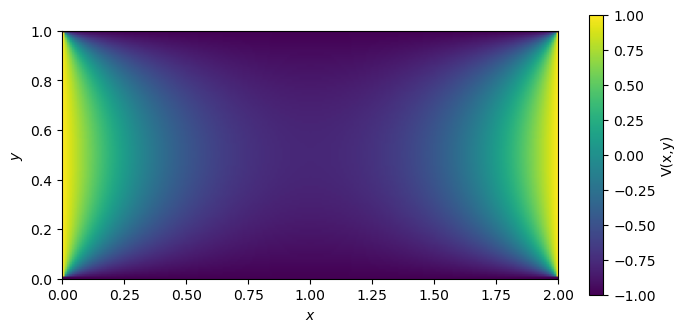

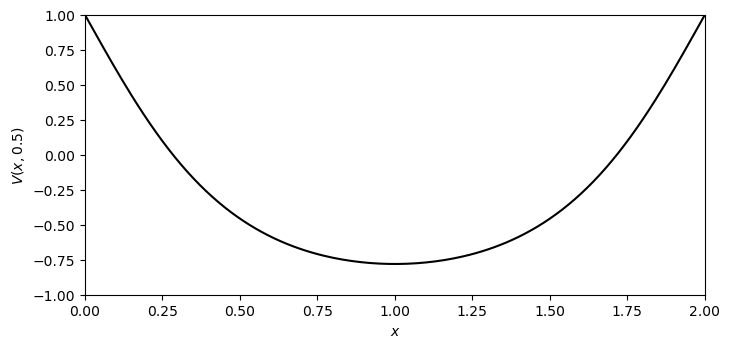

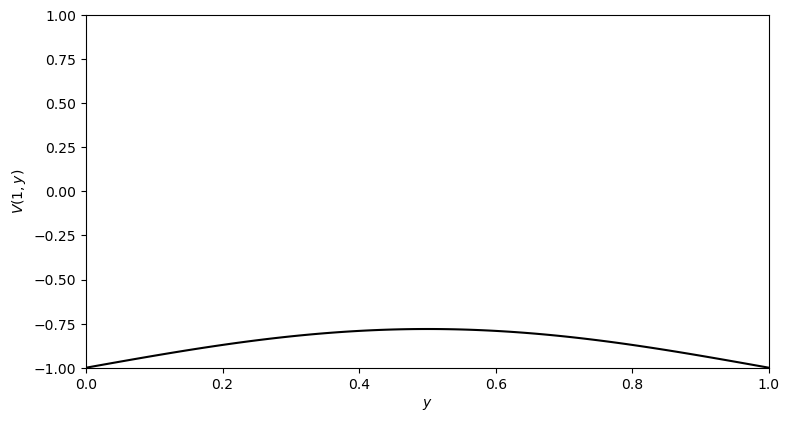

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Grid of x,y points
nx, ny = 201, 101
x = np.linspace(0, 2, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

# Define an initial guess with boundary conditions
Vi = np.zeros((nx,ny))
Vi[0,:] = 1 # V(0,y) = 1
Vi[-1,:] = 1 # V(2,y) = 1
Vi[:,0] = -1 # V(x,0) = -1
Vi[:,-1] = -1 # V(x,1) = -1
for i in range(40000):
    # Compute the 2nd derivative excess
    d2v = (np.roll(Vi,1,axis=0)+np.roll(Vi,-1,axis=0)+np.roll(Vi,1,axis=1)+np.roll(Vi,-1,axis=1))/4.
    # Update the estimate of V
    Vi[1:-1,1:-1] = d2v[1:-1,1:-1]

# Evaluate the 2nd derivative after the last update
d2v = (np.roll(Vi,1,axis=0)+np.roll(Vi,-1,axis=0)+np.roll(Vi,1,axis=1)+np.roll(Vi,-1,axis=1))
print(np.max(np.abs(np.double(d2v-4*Vi)[1:-1,1:-1])))

#Figure 1
fig = plt.figure(figsize = (8,8))
plt.subplot(2,1,1, autoscale_on='auto')
plt.imshow(np.transpose(Vi),vmin=-1,vmax=1,aspect='equal',extent=[0,2,0,1])
plt.xlabel('$x$')
plt.ylabel('$y$')
ax = plt.gca()
cbar = plt.colorbar()
cbar.ax.set_ylabel('V(x,y)')

#Figure 2
fig = plt.figure(figsize = (8,8))
plt.subplot(2,1,1)
plt.plot(x,Vi[:,50],color='k')
plt.xlabel('$x$')
plt.ylabel('$V(x,0.5)$')
plt.xlim(0,2)
plt.ylim(-1,1)

#Figure 3
fig = plt.figure(figsize = (8,8))
plt.subplot(2,1,2)
plt.plot(y,Vi[100,:],color='k')
plt.xlabel('$y$')
plt.ylabel('$V(1,y)$')
plt.xlim(0,1)
plt.ylim(-1,1)

plt.tight_layout()